In [81]:
import pandas as pd
import numpy as numpy
import mysql.connector as sql
import seaborn as sns
import matplotlib.pyplot as plt

In [130]:
sns.set_theme(style="whitegrid")

In [67]:
db = sql.connect(
    host="giniewicz.it",
    user="team07",
    password="te@mlot",
    database="team07",
    port=3306,
)

db.is_connected()

True

In [68]:
cursor = db.cursor()



Połącz bazę danych z wybranym narzędziem (może być inne niż w poprzedniej części!).
1. Znajdź najpopularniejsze rodzaje wypraw, porównaj koszta i zyski, czy są opłacalne?
2. Sporządź wykres liczby obsłużonych klientów w każdym miesiącu działalności firmy, czy firma rośnie, czy podupada?
3. Sprawdź, po których wycieczkach klienci wracają na kolejne, a po których mają dość i więcej ich nie widzicie. Czy są takie, które być może powinny zniknąć z oferty?
4. Postaw i odpowiedz analizą na minimum cztery dodatkowe pytania.



# Znajdź najpopularniejsze rodzaje wypraw, porównaj koszta i zyski, czy są opłacalne?

Wybierzmy 5 najpopularniejszych wypraw.

In [69]:
top_5_trips_query = """
SELECT name, COUNT(*) as trip_count
FROM Trips
GROUP BY name
ORDER BY COUNT(*) DESC
LIMIT 5
"""
cursor.execute(top_5_trips_query)
trips = cursor.fetchall()
top_5_trips_df = pd.DataFrame(trips, columns=[i[0] for i in cursor.description])

In [107]:
top_5_trips_kind_customers_df = pd.DataFrame()
top_5_trips_kind_details_df = pd.DataFrame()

for name in top_5_trips_df['name'].values:
    named_trips_query = f"""
    SELECT trip_id, organization_cost, launch_date, name
    FROM Trips
    WHERE name = '{name}'
    """
    cursor.execute(named_trips_query)
    trip_data = cursor.fetchall()

    top_5_trips_kind_details_df = pd.concat([top_5_trips_kind_details_df, pd.DataFrame(trip_data, columns=[i[0] for i in cursor.description])])

    for trip_id, *_ in trip_data:

        trip_query = f"""
        SELECT participant_id, pesel, trip_id, ticket_price
        FROM TripParticipants 
        WHERE trip_id = {trip_id}
        """
        cursor.execute(trip_query)
        participants = cursor.fetchall()
        top_5_trips_kind_customers_df = pd.concat([top_5_trips_kind_customers_df, pd.DataFrame(participants, columns=[i[0] for i in cursor.description])])

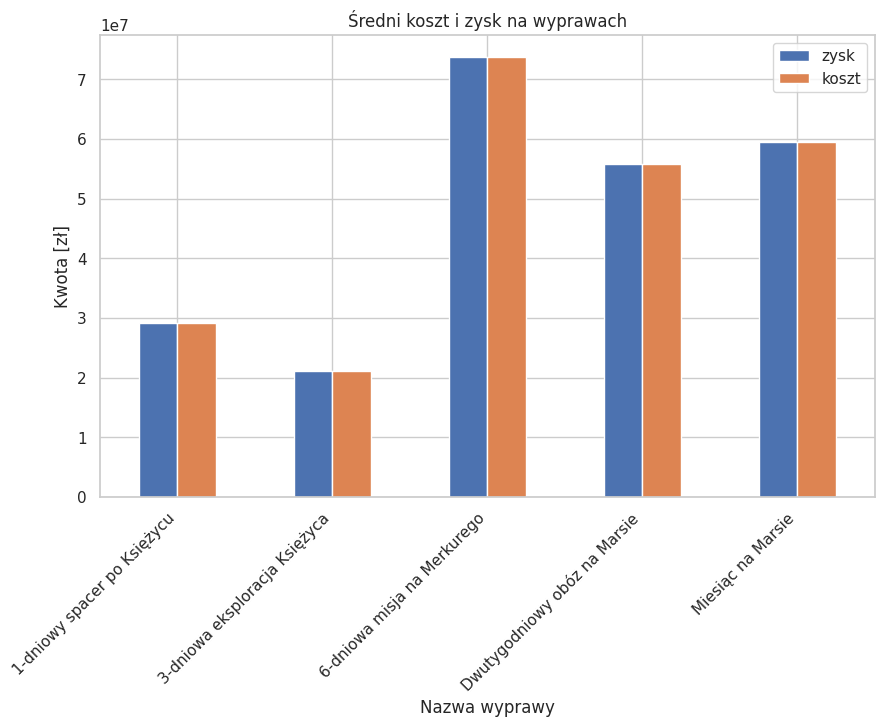

In [ ]:
zyski_koszta =  top_5_trips_kind_customers_df.join(
    top_5_trips_kind_details_df.set_index('trip_id'),
    on='trip_id',
    lsuffix='_customer',
    rsuffix='_details'
).groupby('trip_id').agg(
    _payout =('ticket_price', 'sum'),
    _cost = ('organization_cost', 'first'),
    name = ('name', 'first'),
).groupby('name').agg(
    zysk = ('_payout', 'mean'),
    koszt = ('_cost', 'mean'),
)

ax = zyski_koszta.plot.bar(
    y=['zysk', 'koszt'],
    title='Średni koszt i zysk na wyprawach',
    ylabel='Kwota [zł]',
    xlabel='Nazwa wyprawy',
    figsize=(10, 6),
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

Widzimy, że koszt i zysk wypraw jest praktycznie ten sam. Źle to wróży dla naszej firmy.

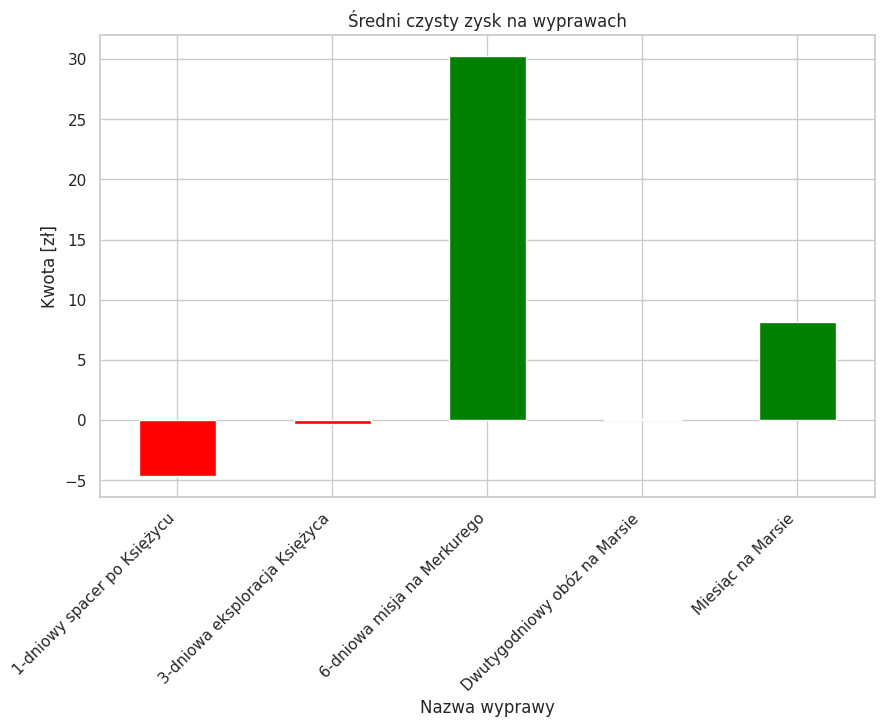

In [136]:
zyski_koszta['czysty_zysk'] = zyski_koszta['zysk'] - zyski_koszta['koszt']
colors = ['red' if x < 0 else 'green' for x in zyski_koszta['czysty_zysk']]
ax = zyski_koszta['czysty_zysk'].plot.bar(
    title='Średni czysty zysk na wyprawach',
    ylabel='Kwota [zł]',
    xlabel='Nazwa wyprawy',
    figsize=(10, 6),
    color=colors
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

Czysty zysk jest naprawdę marginalny w porównaniu z kosztami wyprawy. Firma działa na styk i się nie rozwija.